# IoT Traffic Analysis v8 — Summary-only (No Direction) (UNSW/Dryad)

This notebook implements **v8 summary-only**, but with **direction removed**.

Purpose (ablation): quantify how much the summary model relies on uplink/downlink asymmetry.

Implementation detail:
- We keep the summary feature dimension the same (**Fs=22**) for fair comparison.
- Direction-dependent fields are neutralized by setting every packet's `dir = 0`.
  - This makes `bytes_up = 0`, `pkts_up = 0`, and all up/down ratios collapse.
  - The model still has timing, protocol mix, burstiness, destinations, flow proxies, etc.

If you prefer a different 'no direction' definition (e.g., treating all packets as undirected totals), tell me and I can generate that variant too.


In [6]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import numpy as np
import pandas as pd

from scapy.all import PcapReader
from scapy.layers.inet import IP, TCP, UDP, ICMP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset location
Set `PCAP_DIR` to the folder where you extracted `pcaps.zip` from the Dryad dataset.


In [7]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith('.pcap')])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 26
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) v8 device-type taxonomy + mapping


In [8]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type_v8 = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True

target_types = sorted([t for t in set(device_to_type_v8.values()) if t is not None])
print("v8 target types:", target_types)
print("Counts:", Counter([t for t in device_to_type_v8.values() if t is not None]))


v8 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table from PCAPs


In [9]:
def device_id_from_path(pcap_path: str) -> str:
    return os.path.basename(pcap_path).replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    v8_type = device_to_type_v8.get(dev, None)
    if DROP_NONE_TYPES and v8_type is None:
        continue
    if v8_type is None:
        v8_type = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": v8_type, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device (stratified)


In [10]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:\n", train_df["device_type"].value_counts())
print("Test distribution:\n", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution:
 device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution:
 device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) v8 Summary feature extraction (No Direction)

We compute the same summary feature vector (**Fs=22**) per window, but with all packet directions set to 0.

This means:
- `bytes_up_norm`, `pkts_up_frac` go to 0
- `bytes_down_norm` becomes total-bytes/(n*MTU)
- ratios will collapse toward low values (log-ratio of 0 over something)

Timing, protocol mix, DNS/TLS-like ratios, destination diversity, and flow proxies remain informative.


In [11]:
PKTS_PER_WINDOW = 60
STRIDE = 60
MAX_WINDOWS_PER_DEVICE = 1200

MTU_NORM = 1500.0
IAT_CAP_SECONDS = 2.0
BURST_GAP_SECONDS = 0.5

Fs = 22

def _norm_log1p(x: float, cap: float) -> float:
    x = min(max(x, 0.0), cap)
    return math.log1p(x) / math.log1p(cap)

def _log_ratio(a: float, b: float, clip: float = 1000.0) -> float:
    r = a / (b + 1.0)
    r = min(r, clip)
    return math.log1p(r) / math.log1p(clip)

def iter_summary_windows_no_direction(pcap_path: str,
                                      label: int,
                                      max_windows: int = MAX_WINDOWS_PER_DEVICE,
                                      pkts_per_window: int = PKTS_PER_WINDOW,
                                      stride: int = STRIDE):
    """Yield (summary_vector, label) where per-packet direction is forced to 0."""
    buf = []
    prev_time = None

    def summarize(items):
        n = len(items)
        if n == 0:
            return None

        # direction is always 0 => all bytes are 'down'
        bytes_up = 0.0
        bytes_down = sum(it["plen"] for it in items)
        pkts_up = 0
        pkts_down = n

        iats = [it["iat"] for it in items[1:]]
        if len(iats) == 0:
            iat_mean = iat_std = iat_max = 0.0
        else:
            iat_mean = float(np.mean(iats))
            iat_std = float(np.std(iats))
            iat_max = float(np.max(iats))

        bursts = 1
        for it in items[1:]:
            if it["iat"] > BURST_GAP_SECONDS:
                bursts += 1
        burst_count_norm = bursts / n
        avg_burst_size_norm = (n / bursts) / n

        tcp = sum(1 for it in items if it["proto"] == "tcp")
        udp = sum(1 for it in items if it["proto"] == "udp")
        icmp = sum(1 for it in items if it["proto"] == "icmp")
        other = n - tcp - udp - icmp

        dns_like = sum(1 for it in items if it["dns_like"])
        tls_like = sum(1 for it in items if it["tls_like"])

        unique_dsts = len(set(it["dst"] for it in items if it["dst"] is not None))
        syn_count = sum(1 for it in items if it["syn"])
        rst_count = sum(1 for it in items if it["rst"])

        flows = set(it["flow"] for it in items if it["flow"] is not None)
        flow_count = max(1, len(flows))
        total_bytes = sum(it["plen"] for it in items)
        bytes_per_flow_norm = (total_bytes / flow_count) / MTU_NORM

        bytes_up_norm = bytes_up / (n * MTU_NORM)
        bytes_down_norm = bytes_down / (n * MTU_NORM)
        pkts_up_frac = pkts_up / n
        pkts_down_frac = pkts_down / n

        feat = np.array([
            bytes_up_norm,
            bytes_down_norm,
            pkts_up_frac,
            pkts_down_frac,
            _log_ratio(pkts_up, pkts_down),
            _log_ratio(bytes_up, bytes_down),
            _norm_log1p(iat_mean, IAT_CAP_SECONDS),
            _norm_log1p(iat_std, IAT_CAP_SECONDS),
            _norm_log1p(iat_max, IAT_CAP_SECONDS),
            burst_count_norm,
            avg_burst_size_norm,
            tcp / n,
            udp / n,
            icmp / n,
            other / n,
            dns_like / n,
            tls_like / n,
            unique_dsts / n,
            syn_count / n,
            rst_count / n,
            len(flows) / n,
            bytes_per_flow_norm,
        ], dtype=np.float32)

        assert feat.shape[0] == Fs
        return feat

    windows_yielded = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue

            this_time = float(getattr(pkt, "time", 0.0))
            if prev_time is None or this_time <= 0.0 or prev_time <= 0.0:
                iat = 0.0
            else:
                iat = max(0.0, this_time - prev_time)
            prev_time = this_time
            iat = min(iat, IAT_CAP_SECONDS)

            ip = pkt[IP]
            src = getattr(ip, "src", None)
            dst = getattr(ip, "dst", None)

            plen = float(len(pkt))

            proto_name = "other"
            dns_like = False
            tls_like = False
            syn = False
            rst = False
            flow = None

            if pkt.haslayer(TCP):
                proto_name = "tcp"
                tcp = pkt[TCP]
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                fl = str(tcp.flags)
                syn = ("S" in fl)
                rst = ("R" in fl)
                dns_like = (sport == 53 or dport == 53)
                tls_like = (sport == 443 or dport == 443)
                flow = (src, dst, sport, dport, 6)
            elif pkt.haslayer(UDP):
                proto_name = "udp"
                udp = pkt[UDP]
                sport = int(getattr(udp, "sport", 0))
                dport = int(getattr(udp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = False
                flow = (src, dst, sport, dport, 17)
            elif pkt.haslayer(ICMP):
                proto_name = "icmp"
                flow = (src, dst, 0, 0, 1)
            else:
                flow = (src, dst, 0, 0, int(getattr(ip, "proto", 0)))

            buf.append({
                "plen": plen,
                "iat": iat,
                "proto": proto_name,
                "dns_like": dns_like,
                "tls_like": tls_like,
                "dst": dst,
                "syn": syn,
                "rst": rst,
                "flow": flow,
            })

            if len(buf) >= pkts_per_window:
                feat = summarize(buf[:pkts_per_window])
                if feat is not None:
                    yield feat, label
                    windows_yielded += 1
                    if windows_yielded >= max_windows:
                        break
                buf = buf[stride:]


## 6) tf.data pipeline


In [12]:
def make_window_generator(df_sub: pd.DataFrame):
    def gen():
        for _, row in df_sub.iterrows():
            pcap_path = row["pcap_path"]
            y = int(row["y"])
            for Xs, ys in iter_summary_windows_no_direction(pcap_path, label=y):
                yield Xs, ys
    return gen

output_signature = (
    tf.TensorSpec(shape=(Fs,), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

def make_dataset(df_sub: pd.DataFrame, batch_size: int = 128, shuffle: bool = True):
    ds = tf.data.Dataset.from_generator(make_window_generator(df_sub), output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(4096, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 128
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds)


2026-01-14 23:24:40.348896: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 22), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 7) Model — MLP on summaries


In [13]:
def make_mlp(n_classes: int) -> tf.keras.Model:
    inp = layers.Input(shape=(Fs,), name="summary_features")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.15)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n_classes = len(types)
model = make_mlp(n_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ summary_features (InputLayer)   │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,996 (113.27 KB)

 Trainable params: 28,484 (111.27 KB)

 Non-trainable params: 512 (2.00 KB)

## 8) Train


Epoch 1/40


2026-01-14 23:24:56.275548: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 76 of 4096
2026-01-14 23:25:16.241432: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 241 of 4096
2026-01-14 23:25:36.172248: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 366 of 4096
2026-01-14 23:25:46.181569: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 443 of 4096
2026-01-14 23:25:56.219434: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 557 of 4096
2026-01-14 23:26:16.252736: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while):

    134/Unknown 1356s 7s/step - accuracy: 0.6756 - loss: 0.9195

2026-01-14 23:47:17.521688: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


143/143 ━━━━━━━━━━━━━━━━━━━━ 1550s 8s/step - accuracy: 0.7582 - loss: 0.6890 - val_accuracy: 0.2620 - val_loss: 1.4029 - learning_rate: 0.0010
Epoch 2/40


...

143/143 ━━━━━━━━━━━━━━━━━━━━ 1052s 6s/step - accuracy: 0.8998 - loss: 0.2826 - val_accuracy: 0.3653 - val_loss: 2.3682 - learning_rate: 1.2500e-04
Epoch 11/40


2026-01-15 02:26:49.491656: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 196 of 4096
2026-01-15 02:27:09.466841: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 727 of 4096
2026-01-15 02:27:19.487358: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 971 of 4096
2026-01-15 02:27:29.488601: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1232 of 4096
2026-01-15 02:27:39.490312: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1513 of 4096
2026-01-15 02:27:59.493523: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a whil

143/143 ━━━━━━━━━━━━━━━━━━━━ 1019s 6s/step - accuracy: 0.9060 - loss: 0.2643 - val_accuracy: 0.3646 - val_loss: 2.4219 - learning_rate: 6.2500e-05
Epoch 12/40


2026-01-15 02:43:48.307275: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 224 of 4096
2026-01-15 02:44:08.268556: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 687 of 4096
2026-01-15 02:44:18.293249: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 914 of 4096
2026-01-15 02:44:38.264561: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1367 of 4096
2026-01-15 02:44:48.280900: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1629 of 4096
2026-01-15 02:44:58.305309: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a whil

143/143 ━━━━━━━━━━━━━━━━━━━━ 915s 5s/step - accuracy: 0.9092 - loss: 0.2565 - val_accuracy: 0.3829 - val_loss: 2.4415 - learning_rate: 6.2500e-05


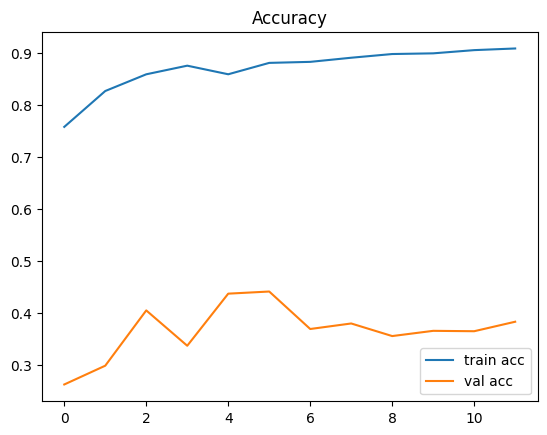

In [14]:
EPOCHS = 40

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()


## 9) Evaluation
Window-level and device-level (mean-prob aggregation) evaluation.


Window-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.3166    0.3950    0.3515       800
interactive_actuators     0.4092    0.4450    0.4263       400
   low_rate_telemetry     0.9146    0.1838    0.3061       408
  smart_media_clients     0.2793    0.3355    0.3048       462

             accuracy                         0.3498      2070
            macro avg     0.4799    0.3398    0.3472      2070
         weighted avg     0.4440    0.3498    0.3466      2070



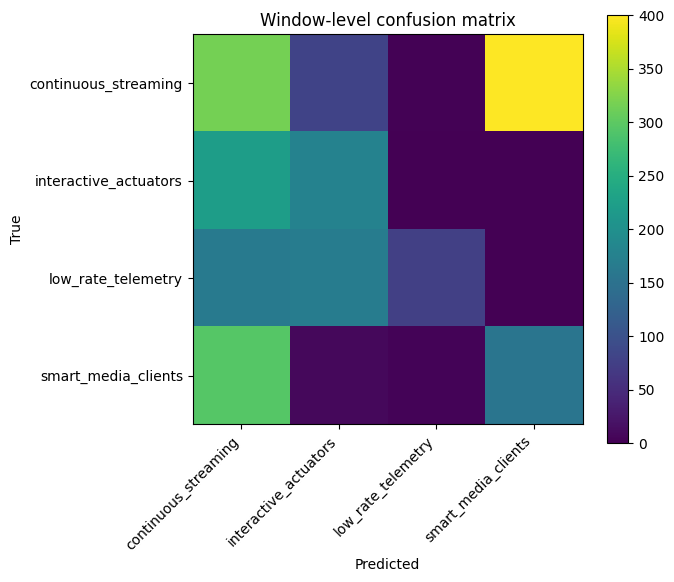


Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=smart_media_clients    windows=400
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=continuous_streaming   windows=400
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=continuous_streaming   windows=400
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=interactive_actuators  windows=8
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=continuous_streaming   windows=62
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=continuous_streaming   windows=400
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   windows=400

Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.2000    0.5000    0.2857         2
interactive_actuators     0.0000    0.0000    0.

/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

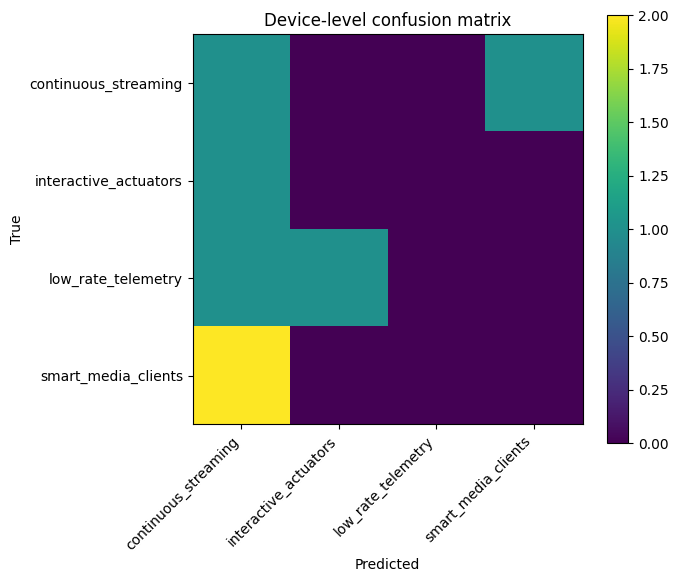

In [15]:
def collect_window_preds(df_sub: pd.DataFrame, model: tf.keras.Model, max_windows_per_device: int = 500):
    all_true = []
    all_pred = []
    per_device = []

    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        pcap_path = row["pcap_path"]

        probs = []
        wcount = 0
        for Xs, ys in iter_summary_windows_no_direction(pcap_path, label=y_true, max_windows=max_windows_per_device):
            p = model.predict(Xs[None, ...], verbose=0)[0]
            probs.append(p)
            y_hat = int(np.argmax(p))
            all_true.append(y_true)
            all_pred.append(y_hat)
            wcount += 1

        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((n_classes,), dtype=np.float32)
            y_dev = -1

        per_device.append((dev, y_true, probs_mean, y_dev, wcount))

    return np.array(all_true), np.array(all_pred), per_device

win_true, win_pred, dev_preds = collect_window_preds(test_df, model, max_windows_per_device=400)

print("Window-level classification report:")
print(classification_report(win_true, win_pred, target_names=types, digits=4))

cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Window-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

dev_true = []
dev_pred = []
print("\nPer-device predictions:")
for dev, y_true, probs_mean, y_dev, wcount in dev_preds:
    if y_dev >= 0:
        dev_true.append(y_true)
        dev_pred.append(y_dev)
    print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} windows={wcount}")

dev_true = np.array(dev_true)
dev_pred = np.array(dev_pred)

print("\nDevice-level classification report (mean-prob aggregation):")
print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm2, interpolation="nearest")
plt.title("Device-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 10) Notes
- This ablation is intentionally harsh: it removes all directional asymmetry.
- If you want a softer ablation, we can instead compute **undirected totals** (e.g., total bytes, total packets) without splitting up/down.
